In [ ]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt


In [2]:
load_dotenv()
engine = create_engine(f"postgresql://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
                       f"@{os.environ['POSTGRES_HOST']}:5433/online_retail")

In [3]:
df = pd.read_sql("""
    SELECT o.customer_id, o.invoice_date, oi.quantity, oi.unit_price
    FROM orders o JOIN order_items oi ON oi.invoice_no = o.invoice_no
    WHERE o.customer_id IS NOT NULL AND NOT o.is_cancelled
""", engine)

In [4]:
df['revenue'] = df['quantity'] * df['unit_price']

In [5]:
snapshot = df['invoice_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_id').agg(
    recency=('invoice_date', lambda x: (snapshot - x.max()).days),
    frequency=('invoice_date', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

In [6]:
segments = ['Утеряны','Под риском','Лояльны','Лучшие']
rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['score'] = rfm['R'] + rfm['F'] + rfm['M']
rfm['segment'] = pd.cut(rfm['score'], bins=[0,6,9,12,15],
                         labels=segments)

In [7]:
rfm

,customer_id,recency,frequency,monetary,R,F,M,score,segment
0,12346,326,3,77352.96,2,3,5,10,Лояльны
1,12347,2,8,5633.32,5,4,5,14,Лучшие
2,12348,75,5,1658.40,3,4,4,11,Лояльны
3,12349,19,3,3678.69,5,3,5,13,Лучшие
4,12350,310,1,294.40,2,1,2,5,Утеряны
...,...,...,...,...,...,...,...,...,...
5844,18283,4,22,2730.70,5,5,4,14,Лучшие
5845,18284,432,1,411.68,1,2,2,5,Утеряны
5846,18285,661,1,377.00,1,2,2,5,Утеряны
5847,18286,477,2,1246.43,1,3,4,8,Под риском


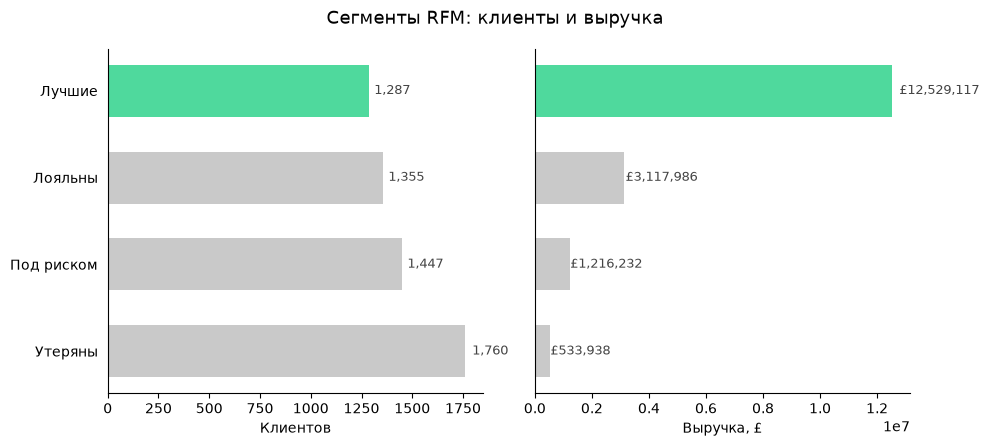

In [8]:
segment_stats = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    revenue=('monetary', 'sum')
).sort_values('revenue', ascending=True)

highlight = segment_stats.index[-1]  # топ-сегмент по выручке — определяется данными, не хардкодится
colors = ["#4fd99d" if seg == highlight else '#c9c9c9' for seg in segment_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, col, label, fmt in zip(
    axes,
    ['customers', 'revenue'],
    ['Клиентов', 'Выручка, £'],
    ['{:,.0f}', '£{:,.0f}']
):
    bars = ax.barh(segment_stats.index, segment_stats[col], color=colors, height=0.6)
    ax.set_xlabel(label)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)
    for bar, value in zip(bars, segment_stats[col]):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                 fmt.format(value), va='center', fontsize=9, color='#444444')

fig.suptitle('Сегменты RFM: клиенты и выручка', fontsize=13)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')